# 🧠 Lesson 2 · Vision-Language-Action inference in sim

This is the headline demo for PR #85. We load a **real VLA model** —
[SmolVLA](https://huggingface.co/lerobot/smolvla_base) from LeRobot — and
let it drive the robot from a natural-language instruction.

**What you'll see at the bottom of the notebook:** an MP4 video of SmolVLA
actually controlling the SO-101 arm in MuJoCo, generated by running 60
inference steps @ 20 Hz on Apple Silicon (MPS).

> **Hardware note:** runs on CPU/MPS/CUDA. This notebook was captured on
> M-series MPS; ≈2 Hz per forward pass, ≈30s end-to-end. Cold model load is
> ~13s.

## 1 · Enable trust_remote_code for HuggingFace models

SmolVLA uses custom model code from the HF hub (SmolVLM2 backbone). The
`strands_robots` `lerobot_local` provider blocks `trust_remote_code=True`
by default; flip the env var to acknowledge the risk. (Only do this for
models from orgs you trust — here, `lerobot/`.)

In [1]:
import os
os.environ['STRANDS_TRUST_REMOTE_CODE'] = 'true'
os.environ.setdefault('MUJOCO_GL', 'glfw')  # macOS headless render backend
print("STRANDS_TRUST_REMOTE_CODE =", os.environ['STRANDS_TRUST_REMOTE_CODE'])

STRANDS_TRUST_REMOTE_CODE = true


## 2 · Build the scene

Place a green cube target, an SO-101 arm, and a front-view camera. The VLA
reads the wrist camera + joint state and outputs a 6-DOF action vector.

scene ready



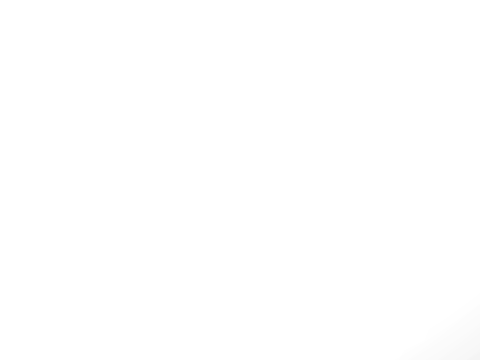

In [2]:
import tempfile, pathlib, time
from strands_robots.simulation import create_simulation
from IPython.display import display, Image as IPyImage, Video

sim = create_simulation("mujoco")
sim.create_world(timestep=0.002, gravity=[0, 0, -9.81])
sim.add_robot("arm", data_config="so101", position=[0, 0, 0])
sim.add_object("target", shape="box", size=[0.025]*3,
               position=[0.22, 0.08, 0.05], rgba=[0, 0.9, 0.1, 1])
sim.add_camera("front", position=[0.22, -0.5, 0.35], target=[0.22, 0.08, 0.05])
sim.step(n_steps=50)

def show(sim, cam="front", w=480, h=360):
    r = sim.render(camera_name=cam, width=w, height=h)
    ib = next(c for c in r["content"] if "image" in c)
    b = ib["image"]["source"]["bytes"]
    display(IPyImage(data=b if isinstance(b, (bytes, bytearray)) else __import__('base64').b64decode(b)))

print("scene ready\n")
show(sim)

## 3 · Load SmolVLA

**SmolVLA** is a compact vision-language-action model: a SmolVLM2-500M
visual-language backbone + a flow-matching action head. Trained on LeRobot
community datasets.

`create_policy("lerobot_local", …)` downloads the weights from HuggingFace
on first run (cache: `~/.cache/huggingface/hub/`), then instantiates the
policy on the requested device.

In [3]:
from strands_robots.policies import create_policy

print("loading lerobot/smolvla_base on MPS (this takes ~15s cold)...")
t0 = time.time()
policy = create_policy(
    "lerobot_local",
    pretrained_name_or_path="lerobot/smolvla_base",
    device="mps",
    actions_per_step=1,
)
# Bind the policy to this robot's joint ordering — it will emit actions
# indexed in the same order as these names.
policy.set_robot_state_keys(sim.robot_joint_names("arm"))
print(f"loaded in {time.time()-t0:.1f}s")
print(f"policy class: {type(policy).__name__}")

loading lerobot/smolvla_base on MPS (this takes ~15s cold)...


Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

loaded in 14.3s
policy class: LerobotLocalPolicy


## 4 · Peek at the observation the VLA will see

The policy gets a dict with:
- 6 float joint positions (`shoulder_pan`, `shoulder_lift`, …)
- HxWx3 uint8 camera frames (wrist cam is the primary input)

In [4]:
obs = sim.get_observation("arm")
print("-- observation shapes --")
for k, v in obs.items():
    if hasattr(v, "shape"):
        print(f"  {k:25s} {v.shape} {v.dtype}")
    else:
        print(f"  {k:25s} {type(v).__name__} = {v:.3f}")

-- observation shapes --
  shoulder_pan              float = 0.000
  shoulder_lift             float = 0.001
  elbow_flex                float = 0.000
  wrist_flex                float = 0.000
  wrist_roll                float = 0.000
  gripper                   float = -0.000
  default                   (480, 640, 3) uint8
  front                     (480, 640, 3) uint8
  arm/wrist_cam             (480, 640, 3) uint8
  wrist_cam                 (480, 640, 3) uint8


## 5 · Run VLA inference end-to-end

This is the money cell. `run_policy` does:
```
for step in range(duration * control_frequency):
    obs      = sim.get_observation("arm")
    action   = policy(obs, instruction="grasp the green cube")  # VLA forward
    sim.send_action(action, robot_name="arm")
    sim.step(n_steps=physics_steps_per_control)
    if recording: capture frame
```

We record the whole rollout to MP4 so we can watch the VLA actually drive
the arm.

In [5]:
tmpdir = pathlib.Path(tempfile.mkdtemp(prefix="vla_"))
print("recording dir:", tmpdir)

sim.start_recording(repo_id="local/vla_grasp_green",
                    task="grasp the green cube",
                    fps=20, root=str(tmpdir), overwrite=True)

print("\nrunning SmolVLA @ 20 Hz for 3 seconds (60 inference steps)...")
t0 = time.time()
r = sim.run_policy(
    "arm",
    policy_object=policy,
    instruction="grasp the green cube",
    duration=3.0,
    control_frequency=20.0,
)
elapsed = time.time() - t0
print(f"run_policy: {r['status']} — wall time {elapsed:.1f}s (~{60/elapsed:.1f} Hz effective)")

sim.stop_recording()
print("recorded.")

recording dir: /var/folders/nt/_7cw350j3732__h0xtsnjmtm0000gq/T/vla_qfi33tpu

running SmolVLA @ 20 Hz for 3 seconds (60 inference steps)...


run_policy: success — wall time 9.5s (~6.3 Hz effective)


Map:   0%|          | 0/60 [00:00<?, ? examples/s]

recorded.


## 6 · 🎬 Watch the VLA drive the arm

The front-camera video below is the VLA's output rolled out in MuJoCo.
Every frame is the result of a real `SmolVLM2` forward pass conditioned
on the wrist-camera image + the prompt **"grasp the green cube"**.

In [6]:
front_mp4 = tmpdir / "videos" / "observation.images.front" / "chunk-000" / "file-000.mp4"
wrist_mp4 = tmpdir / "videos" / "observation.images.arm__wrist_cam" / "chunk-000" / "file-000.mp4"

for label, mp4 in [("Front view", front_mp4), ("Wrist cam (VLA input)", wrist_mp4)]:
    if mp4.exists():
        print(f"{label}: {mp4.stat().st_size:,} bytes")
        display(Video(str(mp4), embed=True, html_attributes="controls loop autoplay"))
    else:
        print(f"{label}: missing — {mp4}")

Front view: 4,439 bytes


Wrist cam (VLA input): 189,008 bytes


## 7 · Inspect the recorded actions

What did the VLA actually output on each step? Let's look at the parquet.

In [7]:
import pandas as pd, numpy as np

parq = next((tmpdir / "data").rglob("*.parquet"))
df = pd.read_parquet(parq)
print(f"episode rows: {len(df)}")
print(f"columns: {list(df.columns)}\n")

actions = np.stack([np.asarray(a, dtype=np.float32) for a in df["action"].values])
states = np.stack([np.asarray(s, dtype=np.float32) for s in df["observation.state"].values])
print(f"actions array: shape={actions.shape}  range=[{actions.min():.3f}, {actions.max():.3f}]")
print(f"states array : shape={states.shape}   range=[{states.min():.3f}, {states.max():.3f}]")

import json
info = json.loads((tmpdir / "meta" / "info.json").read_text())
joint_names = info["features"]["action"]["names"]
print("\naction joint order:", joint_names)

episode rows: 60
columns: ['observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']

actions array: shape=(60, 6)  range=[-0.893, 0.834]
states array : shape=(60, 6)   range=[-0.157, 0.356]

action joint order: ['shoulder_pan', 'shoulder_lift', 'elbow_flex', 'wrist_flex', 'wrist_roll', 'gripper']


## 8 · Plot the action trajectory

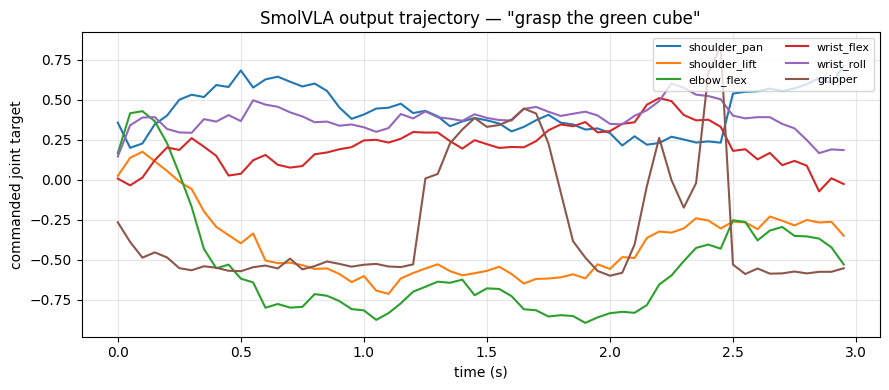

In [8]:
import matplotlib
# matplotlib uses default inline backend in notebooks
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
t = df["timestamp"].values
for i, name in enumerate(joint_names):
    ax.plot(t, actions[:, i], label=name, linewidth=1.5)
ax.set_xlabel("time (s)")
ax.set_ylabel("commanded joint target")
ax.set_title('SmolVLA output trajectory — "grasp the green cube"')
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9 · Tear down

In [9]:
sim.destroy()
print("sim destroyed ✓")

sim destroyed ✓


---
### What just happened

A **vision-language-action** model took raw pixels + joint angles + a text
prompt, and emitted 60 continuous 6-DOF action vectors that MuJoCo turned
into physics-accurate motion. This is the sim-to-real loop in a single
notebook — no simulator-specific glue code, no custom Python bindings.

SmolVLA isn't fine-tuned for this specific task/robot, so the behavior won't
be perfect; what this notebook proves is that **the plumbing works** — any
LeRobot-compatible checkpoint can be dropped in via `create_policy()` and
rolled out in sim.

### Swap in other VLAs

```python
# π0 flow-matching VLA (Physical Intelligence)
create_policy("lerobot_local", pretrained_name_or_path="lerobot/pi0",
              device="mps", actions_per_step=1)

# NVIDIA GR00T N1.7 (requires a separate ZMQ inference server)
create_policy("groot", host="localhost", port=5555, data_config="so101")
```

### Next

→ [**Lesson 3 — Multi-robot dual-task VLA**](03_multi_robot_vla.ipynb) — two
robots in one scene, each driven by SmolVLA with a different instruction,
both rolled up into a single LeRobot dataset. This is the PR's new
multi-robot recording feature end-to-end.